# Research: Funding Rate Snipe Project

This notebook will do research about the existence of an edge with crypto funding rates of perpetual futures contracts (perps).

# Exchange

For this project we will use the crypto currency exchange Bitget. Bitget offers small trading fees, while being a large, trustworthy platform.
| Exchange | Spot maker | Spot taker | Perpetual maker | Perpetual taker | Notes |
| --- | ---: | ---: | ---: | ---: | --- |
| Binance | 0.10% | 0.10% | 0.02% | 0.05% | Large liquidity, widely used |
| Bitget | 0.10% | 0.10% | 0.02% | 0.06% | Often competitive for perpetual futures |
| Bybit | 0.10% | 0.10% | 0.02% | 0.055% | Strong perpetuals focus |
| OKX | 0.08% | 0.10% | 0.02% | 0.05% | Competitive fees, broad market |
| Coinbase Advanced | 0.40% | 0.60% | N/A | N/A | Higher retail fees, lower crypto focus |

The fees suggest, that all of the first 4 exchanges could be picked. To further investigate, we will look into a coin that paid out a funding rate around $\pm 1$ and check the trading volume. That is important as a large trading volume will allow us to execute large positions without changing the funding rate nor the contract price.

**STORJUSDT on 24.08.2026 at 22:00**
| Exchange | last funding rate | 24h trading volume |
| --- | ---: | ---: |
| Binance | -1.0986% | 60.965172 Mio $ | 
| Bitget | -1.0862% | 60.562908 Mio $ | 
| Bybit | **different payout time** | **arbitrage opportunity?** | 
| OKX | coin not available | - | 

As fees, funding rates and trading volumes are very similar for BitGet and Binance we can pick any of these two and will proceed with **BitGet**.

# Historical Funding Rate Payouts Analysis: Potential Payoff, Fees, Volume, Spread, Market Movement
For this we will fetch the relevant data of a few different coins with relevant funding rates from Bitget and analyze the data.

- ACEUSDT
- HOMEUSDT
- BICOUSDT

**Data fetch using Bitget API**

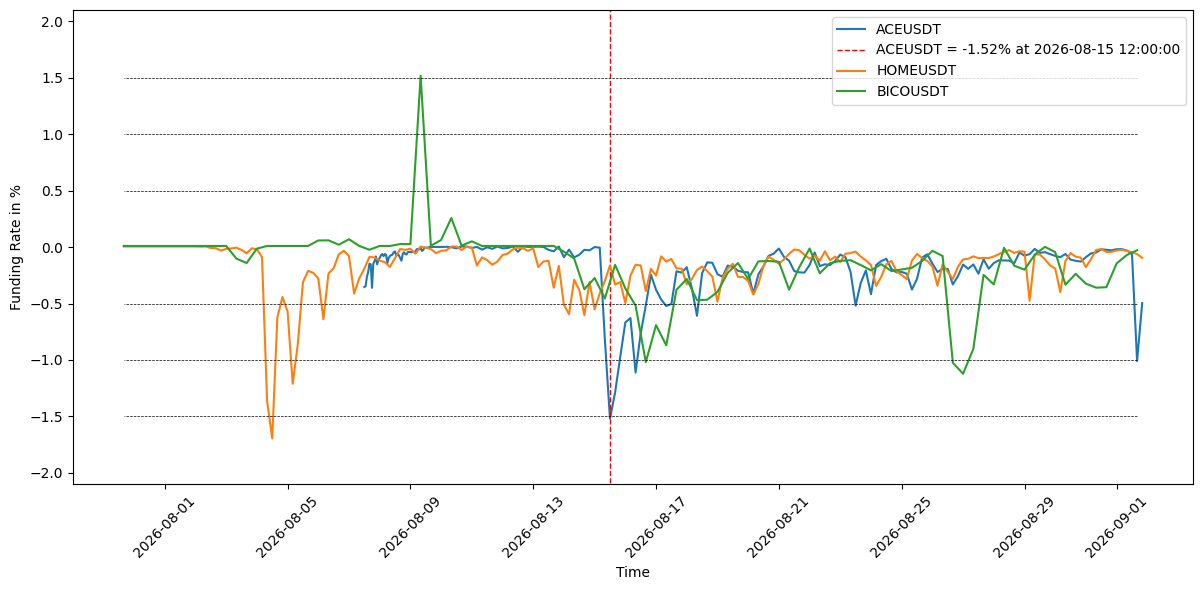

In [1]:
import requests
import numpy as np
from datetime import datetime, timezone
import matplotlib.pyplot as plt

url = 'https://api.bitget.com/api/v2/mix/market/history-fund-rate'

symbols = ['ACEUSDT', 'HOMEUSDT', 'BICOUSDT']
historical_rates_all = {}
plt.figure(figsize=(12, 6))

for symbol in symbols:
    response = requests.get(
        url,
        params={
            'symbol': symbol,
            'productType': 'USDT-FUTURES',
            'pageSize': 100,
            'pageNo': 1
        }
    )

    historical_rates = response.json().get('data', [])

    timestamps = np.array([datetime.fromtimestamp(int(entry['fundingTime']) / 1000,
    tz=timezone.utc) for entry in historical_rates])
    rates = np.array([float(entry['fundingRate']) for entry in historical_rates])

    period = int(abs((int(historical_rates[1]['fundingTime']) - int(historical_rates[0]['fundingTime'])))/1000/60/60)
    if period == 4:
        response_ = requests.get(
                url,
                params={
                    'symbol': symbol,
                    'productType': 'USDT-FUTURES',
                    'pageSize': 100,
                    'pageNo': 2
                }
            )
        timestamps_ = np.array([datetime.fromtimestamp(int(entry['fundingTime']) / 1000,
        tz=timezone.utc) for entry in response_.json().get('data', [])])
        rates_ = np.array([float(entry['fundingRate']) for entry in response_.json().get('data', [])])
        timestamps = np.concatenate((timestamps, timestamps_))
        rates = np.concatenate((rates, rates_))
        

    historical_rates_all[symbol] = {
        'timestamps': timestamps,
        'rates': rates
    }

    plt.plot(timestamps, np.array(rates)*100, label=symbol)
    plt.xlabel('Time')
    plt.ylabel('Funding Rate in %')
    plt.xticks(rotation=45)
    plt.tight_layout()

    if symbol == 'ACEUSDT':
        args = np.argwhere(abs(np.array(rates)) >= 0.015).flatten()
        # plt.scatter(timestamps[args], np.array(rates)[args]*100, color='red', s=10, label=f'{symbol} > 1.5%')
        plt.vlines([timestamps[args[0]]], -3, 3, color='red', linewidth=1, linestyle='--', label=f'{symbol} = {np.array(rates)[args[0]]*100:.2f}% at {timestamps[args[0]].strftime("%Y-%m-%d %H:%M:%S")}')

plt.ylim(-2.1, 2.1)
plt.hlines([1.5, 1., 0.5, -0.5, -1., -1.5], timestamps[0], timestamps[-1], color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.show()


To be able to say something about a potential profit for a certain funding rate $f$, extreme events for $|f|>\varepsilon$ need to be investigated further regarding:
- $f$ $\rightarrow$ potential relative profit
- perp price movement $\rightarrow$ directional risk
- perp trading volume $\rightarrow$ spread and price distortion risk

The funding rate $f=-1.52 \%$ spike of ACEUSDT at 2026-08-15 12:00:00 is investigated, regarding its spot and perp data.

In [2]:
import requests, time
import pandas as pd
from datetime import datetime, timezone
import os

symbol = 'ACEUSDT'
BASE = "https://api.bitget.com"

files = {
    "spot_sell": f"{symbol.lower()}_spot_sell.csv",
    "spot_buy": f"{symbol.lower()}_spot_buy.csv",
    "futures_sell": f"{symbol.lower()}_futures_sell.csv",
    "futures_buy": f"{symbol.lower()}_futures_buy.csv",
}

def fetch_fills_history(symbol, product_type, start_ms, end_ms):
    trades_sell = []
    trades_buy = []
    id_less_than = None
    while True:
        params = {"symbol": symbol}
        if id_less_than:
            params["idLessThan"] = id_less_than
        params["startTime"] = start_ms
        params["endTime"] = end_ms

        if product_type == "USDT-FUTURES":
            url = f"{BASE}/api/v2/mix/market/fills-history"
            params["productType"] = product_type
        elif product_type == "USDT-SPOT":
            url = f"{BASE}/api/v2/spot/market/fills-history"
        else:
            raise ValueError("Invalid product_type. Must be 'USDT-FUTURES' or 'USDT-SPOT'.")

        r = requests.get(url, params=params).json()
        data = r.get("data", [])
        if not data:
            break
        for trade in data:
            if trade["side"] == "Sell":
                trades_sell.append(trade)
            else:
                trades_buy.append(trade)

        id_less_than = data[-1]["tradeId"]
        time.sleep(0.05)
    return pd.DataFrame(trades_sell), pd.DataFrame(trades_buy)

def enrich(df):
    df = df.copy()
    df["ts"] = pd.to_datetime(df["ts"].astype(float), unit="ms")
    df["price"] = df["price"].astype(float)
    df["size"] = df["size"].astype(float)
    df["notional_usdt"] = df["size"] * df["price"]
    return df

if not all(os.path.exists(f) for f in files.values()):
    start_time = datetime(2026, 8, 15, 11, 40, tzinfo=timezone.utc)
    end_time = datetime(2026, 8, 15, 12, 20, tzinfo=timezone.utc)
    start_ms = int(start_time.timestamp() * 1000)
    end_ms = int(end_time.timestamp() * 1000)

    df_sell_unsorted, df_buy_unsorted = fetch_fills_history(
        symbol, product_type="USDT-SPOT", start_ms=start_ms, end_ms=end_ms
    )
    df_sell_unsorted = enrich(df_sell_unsorted)
    df_buy_unsorted = enrich(df_buy_unsorted)

    df_futures_sell_unsorted, df_futures_buy_unsorted = fetch_fills_history(
        symbol, product_type="USDT-FUTURES", start_ms=start_ms, end_ms=end_ms
    )
    df_futures_sell_unsorted = enrich(df_futures_sell_unsorted)
    df_futures_buy_unsorted = enrich(df_futures_buy_unsorted)

    df_sell_unsorted.to_csv(files["spot_sell"], index=False)
    df_buy_unsorted.to_csv(files["spot_buy"], index=False)
    df_futures_sell_unsorted.to_csv(files["futures_sell"], index=False)
    df_futures_buy_unsorted.to_csv(files["futures_buy"], index=False)

else:
    df_sell_unsorted = pd.read_csv(files["spot_sell"], parse_dates=["ts"])
    df_buy_unsorted = pd.read_csv(files["spot_buy"], parse_dates=["ts"])
    df_futures_sell_unsorted = pd.read_csv(files["futures_sell"], parse_dates=["ts"])
    df_futures_buy_unsorted = pd.read_csv(files["futures_buy"], parse_dates=["ts"])

In [3]:
df_sell = df_sell_unsorted.set_index("ts").sort_index()
df_buy = df_buy_unsorted.set_index("ts").sort_index()
df_futures_sell = df_futures_sell_unsorted.set_index("ts").sort_index()
df_futures_buy = df_futures_buy_unsorted.set_index("ts").sort_index()

def plot_zoomed_trades(spot_sell, spot_buy, futures_sell, futures_buy, zoom_start, zoom_end):
    spot_zoom_sell = spot_sell.loc[zoom_start:zoom_end]
    spot_zoom_buy = spot_buy.loc[zoom_start:zoom_end]
    futures_zoom_sell = futures_sell.loc[zoom_start:zoom_end]
    futures_zoom_buy = futures_buy.loc[zoom_start:zoom_end]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    ax1.plot(futures_zoom_sell.index, futures_zoom_sell["price"], label="Perp sell")
    ax1.plot(futures_zoom_buy.index, futures_zoom_buy["price"], label="Perp buy")
    ax1.plot(spot_zoom_sell.index, spot_zoom_sell["price"], label="Spot sell")
    ax1.plot(spot_zoom_buy.index, spot_zoom_buy["price"], label="Spot buy")
    ax1.axvline(pd.Timestamp("2026-08-15 12:00:00"), color="red", linestyle="--")
    ax1.set_ylabel("Price in USDT")
    ax1.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, 1.15))

    ax2.plot(futures_zoom_sell.index, futures_zoom_sell["notional_usdt"], label="Perp sell")
    ax2.plot(futures_zoom_buy.index, futures_zoom_buy["notional_usdt"], label="Perp buy")
    ax2.plot(spot_zoom_sell.index, spot_zoom_sell["notional_usdt"], label="Spot sell")
    ax2.plot(spot_zoom_buy.index, spot_zoom_buy["notional_usdt"], label="Spot buy")
    ax2.axvline(pd.Timestamp("2026-08-15 12:00:00"), color="red", linestyle="--")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Trade size in USDT")

    plt.tight_layout()
    plt.show()
    plt.close()

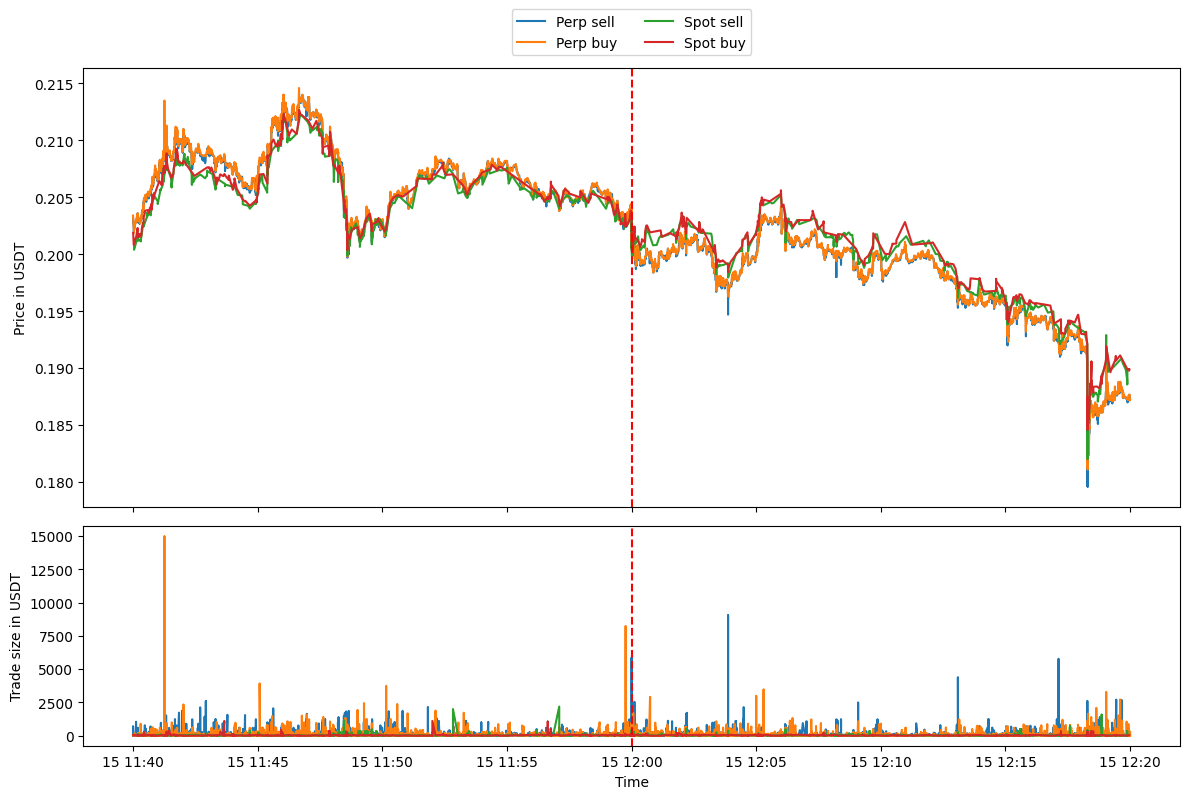

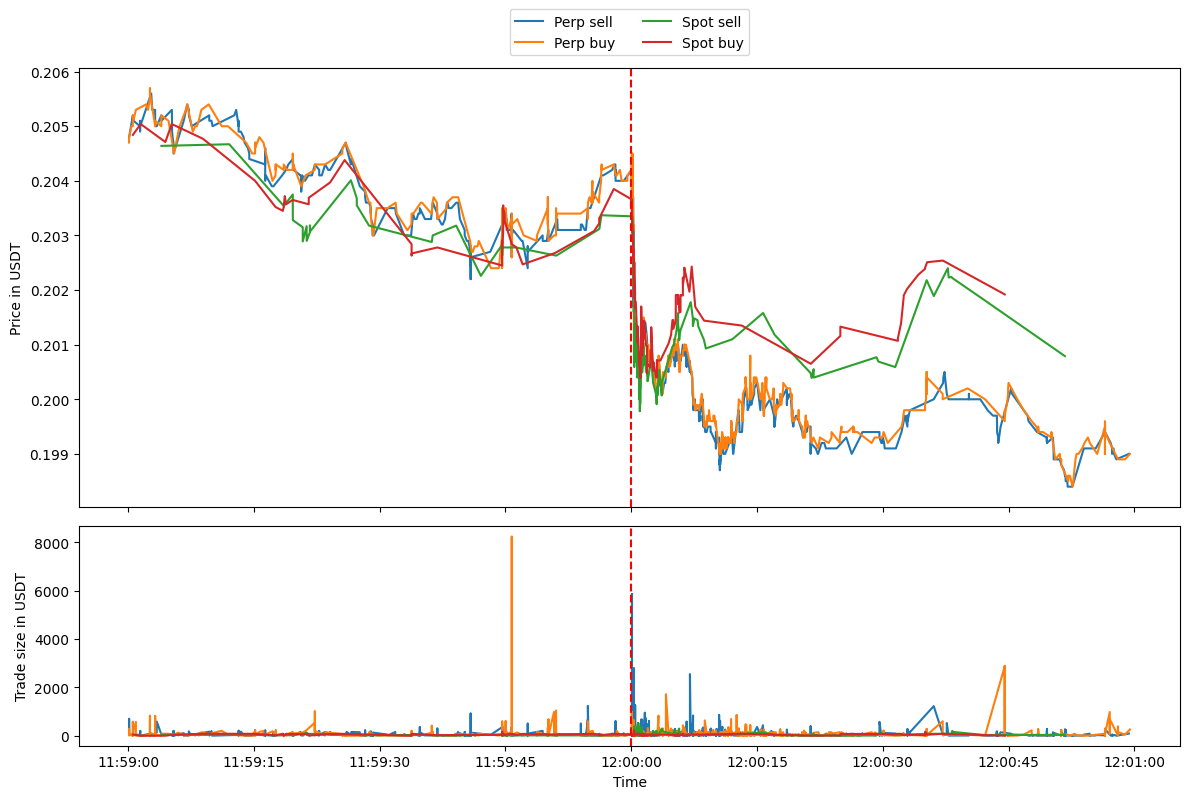

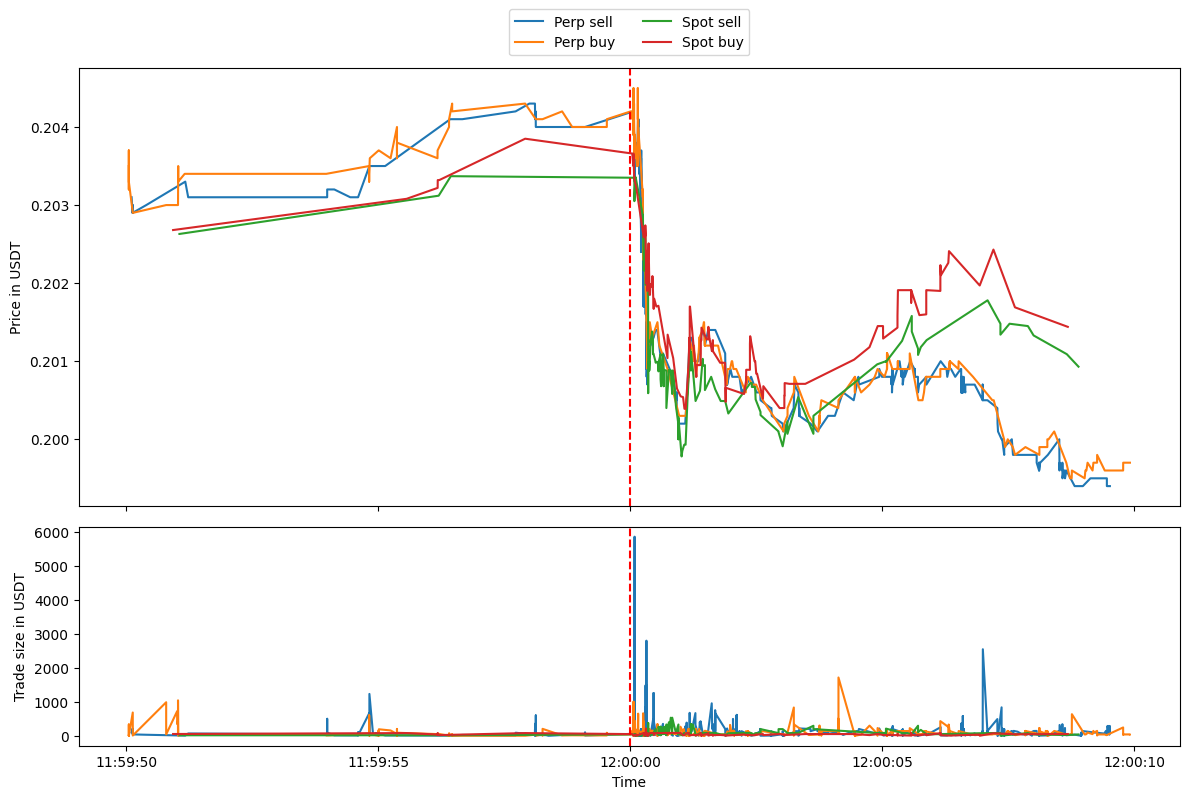

In [4]:
zoom_start_1 = pd.Timestamp("2026-08-15 11:40:00")
zoom_end_1 = pd.Timestamp("2026-08-15 12:20:00")
plot_zoomed_trades(df_sell, df_buy, df_futures_sell, df_futures_buy, zoom_start=zoom_start_1, zoom_end=zoom_end_1)

zoom_start_2 = pd.Timestamp("2026-08-15 11:59:00")
zoom_end_2 = pd.Timestamp("2026-08-15 12:01:00")
plot_zoomed_trades(df_sell, df_buy, df_futures_sell, df_futures_buy, zoom_start=zoom_start_2, zoom_end=zoom_end_2)

zoom_start_3 = pd.Timestamp("2026-08-15 11:59:50")
zoom_end_3 = pd.Timestamp("2026-08-15 12:00:10")
plot_zoomed_trades(df_sell, df_buy, df_futures_sell, df_futures_buy, zoom_start=zoom_start_3, zoom_end=zoom_end_3)

# Remark

At this point clarification is necessary for us to keep track of what these different prices mean for executing potential trades. A distinction between spot and perp is not necessary, as the principle is the same. 

Mechanics to execute long and short positions:
+ Long: Asset is bought (open) and sold (close).
+ Short: Asset is borrowed from the exchange and immediately sold for the exchange partner (e.g. USDT) (open) and the asset is bought and given back to the exchange (close).

## Buy
That means a buy order has been filled. It can mean two different things:
+ A long position has been opened
+ A short position has been closed

In both cases the underlying asset is bought.

## Sell
That means a sell order has been filled. It can mean two different things:
+ A long position has been closed
+ A short position has been opened

In both cases the underlying asset is sold.

# Hypothesis

* Identify $|f|>\varepsilon$ 
* Starting from time $t$ before next funding rate payout scan for enter opportunity:
    + if $f>0$ then look for price difference of perp, sell $p_\text{p, s}$ and spot buy $p_\text{s, b}$ fullfilling $|p_\text{p, s} - p_\text{s, b}| < \delta$
    + if $f<0$ then look for price difference of perp, buy $p_\text{p, b}$ and spot sell $p_\text{s, s}$ fullfilling $|p_\text{p, b} - p_\text{s, s}| < \delta$
* After funding rate payout wait for an analogue exit opportunity with $\delta$

It remains to estimate optimal values for $\varepsilon, t, \delta$